1. Imports, Device, Dataset

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import os
import json
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F

from glob import glob
from google.colab import userdata
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader, random_split

# reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

# device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("using device:", device)

!pip install -q kaggle

# secret key
KAGGLE_USERNAME = "iclallalala"
KAGGLE_KEY = userdata.get("seminer")

os.makedirs("/root/.kaggle", exist_ok=True)
with open("/root/.kaggle/kaggle.json", "w") as f:
    json.dump({
        "username": KAGGLE_USERNAME,
        "key": KAGGLE_KEY
    }, f)
os.chmod("/root/.kaggle/kaggle.json", 600)

# download and unzip dataset
DATASET_SLUG = "orvile/inme-veri-seti-stroke-dataset"
ZIP_NAME = "inme-veri-seti-stroke-dataset.zip"
EXTRACT_DIR = "stroke_data"

!kaggle datasets download -d {DATASET_SLUG}
!unzip -o -q {ZIP_NAME} -d {EXTRACT_DIR}

print("Dataset downloaded and extracted.")

# path check
paths_to_check = [
    "stroke_data",
    "stroke_data/İNME VERİ SETİ",
    "stroke_data/İNME VERİ SETİ/İnme Yok",
    "stroke_data/İNME VERİ SETİ/İskemi/PNG",
    "stroke_data/İNME VERİ SETİ/Kanama/PNG",
]

print("\nPath check:")
for p in paths_to_check:
    print(f"{p} -> {os.path.exists(p)}")

# dataset class
class StrokeDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.image_paths = []
        self.labels = []
        self.transform = transform

        base_path = os.path.join(root_dir, "İNME VERİ SETİ")

        healthy_dir = os.path.join(base_path, "İnme Yok")
        ischemic_dir = os.path.join(base_path, "İskemi", "PNG")
        hemorrhagic_dir = os.path.join(base_path, "Kanama", "PNG")

        print("\nChecking dataset folders...")
        print("Base path       :", base_path, os.path.exists(base_path))
        print("Healthy dir     :", healthy_dir, os.path.exists(healthy_dir))
        print("Ischemic dir    :", ischemic_dir, os.path.exists(ischemic_dir))
        print("Hemorrhagic dir :", hemorrhagic_dir, os.path.exists(hemorrhagic_dir))

        healthy_imgs = glob(os.path.join(healthy_dir, "**", "*.png"), recursive=True)
        ischemic_imgs = glob(os.path.join(ischemic_dir, "*.png"))
        hemorrhagic_imgs = glob(os.path.join(hemorrhagic_dir, "*.png"))

        print("Found healthy pngs    :", len(healthy_imgs))
        print("Found ischemic pngs   :", len(ischemic_imgs))
        print("Found hemorrhagic pngs:", len(hemorrhagic_imgs))

        for img_path in healthy_imgs:
            self.image_paths.append(img_path)
            self.labels.append(0)

        for img_path in ischemic_imgs:
            self.image_paths.append(img_path)
            self.labels.append(1)

        for img_path in hemorrhagic_imgs:
            self.image_paths.append(img_path)
            self.labels.append(1)

        print(f"\nDataset Stats: {len(self.image_paths)} slices loaded.")
        print(f"Healthy: {self.labels.count(0)} | Stroke: {self.labels.count(1)}")

        if len(self.image_paths) == 0:
            raise RuntimeError(
                "No images were found. Check folder names and dataset path."
            )

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = cv2.imread(self.image_paths[idx], cv2.IMREAD_GRAYSCALE)

        if img is None:
            raise RuntimeError(f"Image could not be read: {self.image_paths[idx]}")

        img = cv2.resize(img, (224, 224)).astype(np.float32) / 255.0

        if self.transform:
            img = self.transform(img)
        else:
            img = torch.tensor(img, dtype=torch.float32).unsqueeze(0)

        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return img, label

# transform
transform = transforms.Compose([
    transforms.ToTensor()
])

# dataset
full_ds = StrokeDataset("stroke_data", transform=transform)

# train-test split
train_size = int(0.8 * len(full_ds))
test_size = len(full_ds) - train_size

train_ds, test_ds = random_split(full_ds, [train_size, test_size])

# dataloaders
train_loader = DataLoader(
    train_ds,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=1,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"\nTrain size: {len(train_ds)}")
print(f"Test size : {len(test_ds)}")
print("DataLoaders are ready.")

using device: cuda
Dataset URL: https://www.kaggle.com/datasets/orvile/inme-veri-seti-stroke-dataset
License(s): other
inme-veri-seti-stroke-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
Dataset downloaded and extracted.

Path check:
stroke_data -> True
stroke_data/İNME VERİ SETİ -> True
stroke_data/İNME VERİ SETİ/İnme Yok -> True
stroke_data/İNME VERİ SETİ/İskemi/PNG -> True
stroke_data/İNME VERİ SETİ/Kanama/PNG -> True

Checking dataset folders...
Base path       : stroke_data/İNME VERİ SETİ True
Healthy dir     : stroke_data/İNME VERİ SETİ/İnme Yok True
Ischemic dir    : stroke_data/İNME VERİ SETİ/İskemi/PNG True
Hemorrhagic dir : stroke_data/İNME VERİ SETİ/Kanama/PNG True
Found healthy pngs    : 4551
Found ischemic pngs   : 1130
Found hemorrhagic pngs: 1093

Dataset Stats: 6774 slices loaded.
Healthy: 4551 | Stroke: 2223

Train size: 5419
Test size : 1355
DataLoaders are ready.


2. Model, Training

In [2]:
class TrustNetBlock(nn.Module):
    def __init__(self, in_c, out_c, stride=1, dropout_p=0.3):
        super().__init__()
        self.conv = nn.Conv2d(in_c, out_c, kernel_size=3, stride=stride, padding=1)
        self.bn = nn.BatchNorm2d(out_c)
        self.relu = nn.ReLU(inplace=True)
        self.dropout = nn.Dropout2d(dropout_p)

        self.skip = nn.Sequential()
        if in_c != out_c or stride != 1:
            self.skip = nn.Sequential(
                nn.Conv2d(in_c, out_c, kernel_size=1, stride=stride),
                nn.BatchNorm2d(out_c)
            )

    def forward(self, x):
        out = self.conv(x)
        out = self.bn(out)
        out = self.relu(out)
        out = self.dropout(out)
        out = out + self.skip(x)
        return self.relu(out)


class PerceptionAgent(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            TrustNetBlock(1, 32, stride=1),     # 224
            TrustNetBlock(32, 64, stride=2),    # 112
            TrustNetBlock(64, 128, stride=2),   # 56
            TrustNetBlock(128, 128, stride=2),  # 28
            TrustNetBlock(128, 128, stride=1)   # 28
        )
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(128, 2)

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        return self.fc(x)


model = PerceptionAgent().to(device)

# class weights
labels_np = np.array(full_ds.labels)
class_counts = np.bincount(labels_np)
class_weights = torch.tensor(
    [len(labels_np) / (2 * class_counts[0]), len(labels_np) / (2 * class_counts[1])],
    dtype=torch.float32
).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

epochs = 8

print("Training is starting...")
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for imgs, labels in train_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    print(f"Epoch {epoch+1}/{epochs} - Loss: {epoch_loss:.4f} - Train Acc: {epoch_acc:.4f}")

print("Training complete.")

Training is starting...
Epoch 1/8 - Loss: 0.6767 - Train Acc: 0.5769
Epoch 2/8 - Loss: 0.6496 - Train Acc: 0.6014
Epoch 3/8 - Loss: 0.6503 - Train Acc: 0.6056
Epoch 4/8 - Loss: 0.6394 - Train Acc: 0.6298
Epoch 5/8 - Loss: 0.6368 - Train Acc: 0.6317
Epoch 6/8 - Loss: 0.6269 - Train Acc: 0.6459
Epoch 7/8 - Loss: 0.6172 - Train Acc: 0.6562
Epoch 8/8 - Loss: 0.6159 - Train Acc: 0.6498
Training complete.


3. MC Dropout inference + Grad-CAM

In [3]:
def enable_dropout_only(module):
    if isinstance(module, (nn.Dropout, nn.Dropout2d)):
        module.train()


def agentic_inference(model, image, n_passes=20, threshold=0.45):
    """
    MC Dropout + Entropy-based abstention
    """
    model.eval()
    model.apply(enable_dropout_only)

    stochastic_preds = []

    with torch.no_grad():
        for _ in range(n_passes):
            output = model(image.to(device))
            probs = torch.softmax(output, dim=1)
            stochastic_preds.append(probs.cpu().numpy())

    stochastic_preds = np.stack(stochastic_preds, axis=0)   # [T, B, C]
    mean_prob = np.mean(stochastic_preds, axis=0)           # [B, C]
    entropy = -np.sum(mean_prob * np.log(mean_prob + 1e-10), axis=1)

    pred_class = int(np.argmax(mean_prob, axis=1)[0])
    entropy_val = float(entropy[0])

    if entropy_val > threshold:
        decision = "REFERRED_TO_CLINICIAN"
    else:
        decision = "STROKE_DETECTED" if pred_class == 1 else "NORMAL"

    return decision, entropy_val, mean_prob, pred_class


class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None

        self.forward_hook = self.target_layer.register_forward_hook(self._save_activation)
        self.backward_hook = self.target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, class_idx=None):
        self.model.eval()
        self.model.zero_grad()

        output = self.model(input_tensor)

        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        score = output[:, class_idx]
        score.backward()

        gradients = self.gradients[0]   # [C, H, W]
        activations = self.activations[0]  # [C, H, W]

        weights = gradients.mean(dim=(1, 2))  # [C]

        cam = torch.zeros(activations.shape[1:], dtype=torch.float32, device=activations.device)
        for i, w in enumerate(weights):
            cam += w * activations[i]

        cam = F.relu(cam)
        cam = cam.detach().cpu().numpy()

        cam -= cam.min()
        cam /= (cam.max() + 1e-8)

        return cam, class_idx

    def remove_hooks(self):
        self.forward_hook.remove()
        self.backward_hook.remove()


def overlay_gradcam(img_tensor, cam):
    """
    img_tensor: [1,1,H,W] or [1,H,W]
    cam: [h,w]
    """
    img = img_tensor.squeeze().cpu().numpy()

    cam_resized = cv2.resize(cam, (img.shape[1], img.shape[0]))
    heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    img_uint8 = np.uint8(255 * img)
    img_rgb = cv2.cvtColor(img_uint8, cv2.COLOR_GRAY2RGB)

    overlay = cv2.addWeighted(img_rgb, 0.65, heatmap, 0.35, 0)

    return img_rgb, heatmap, overlay

4. Test sample, prediction, uncertainty, Grad-CAM visualization

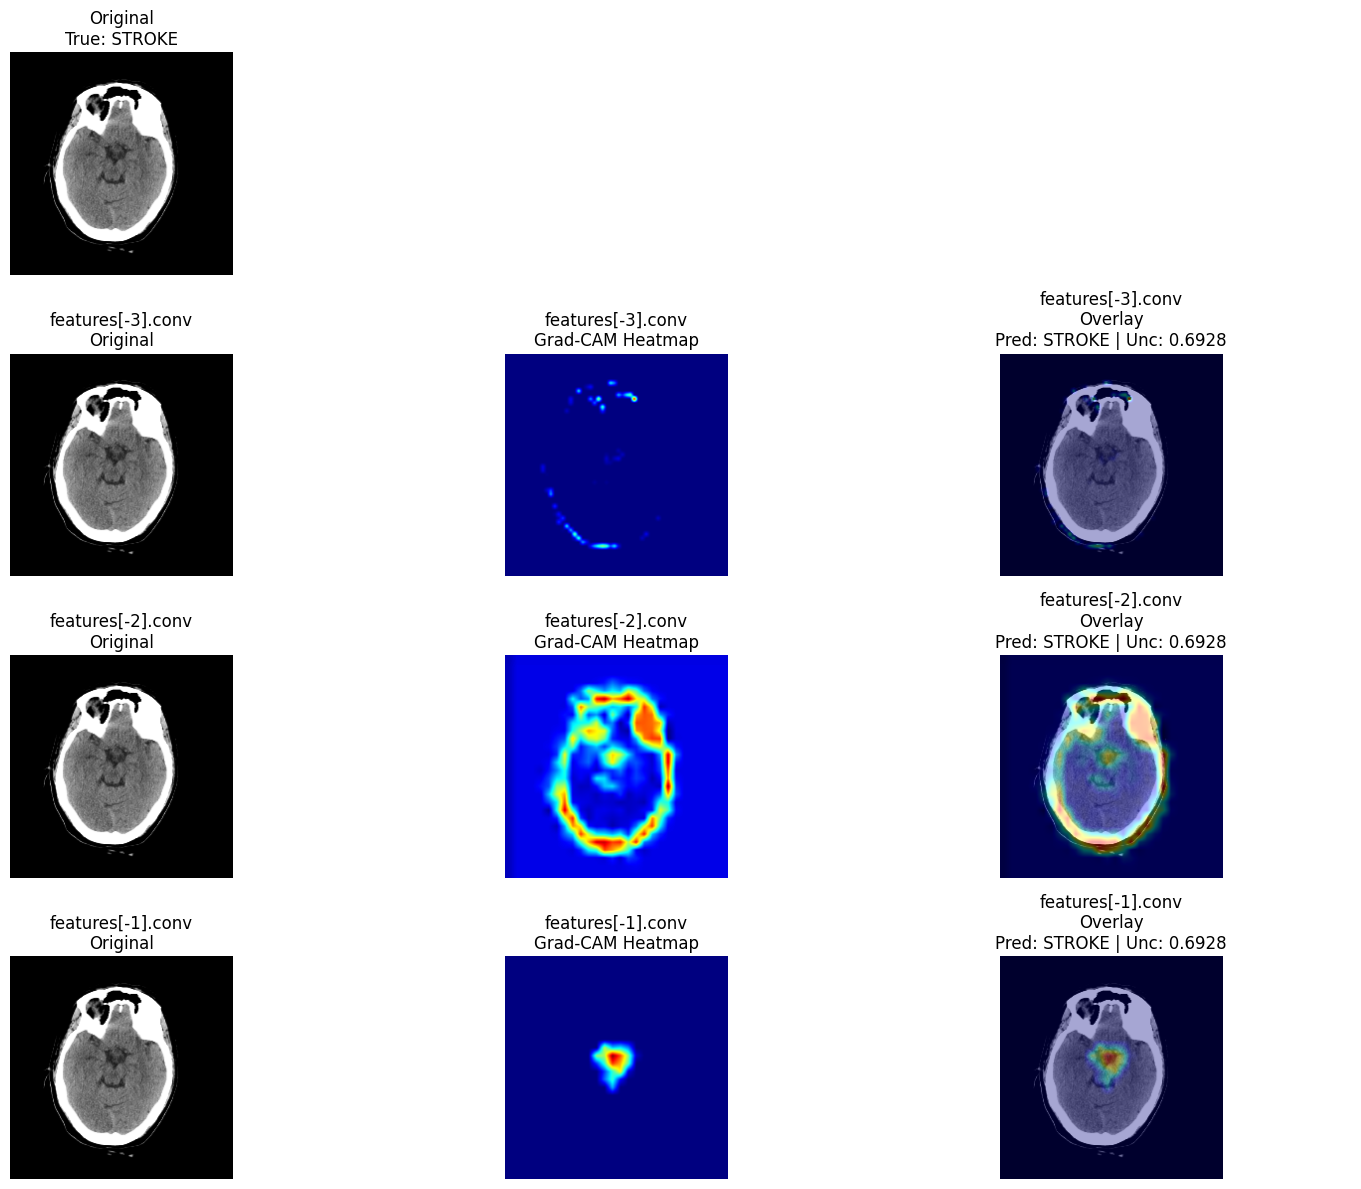

.... Final Prediction Summary ....
True Label      : STROKE
Predicted Label : STROKE
Decision        : REFERRED_TO_CLINICIAN
Uncertainty     : 0.6928
P(Normal)       : 0.4875
P(Stroke)       : 0.5125
Human-in-the-loop required: uncertainty exceeds safety threshold.


In [4]:
# --- Select a stroke sample + compare Grad-CAM layers ---
"""
This cell was kept as an experimental explainability step to compare Grad-CAM outputs from multiple convolutional layers.
The goal was to identify which layer provides the most meaningful medical localization.
Earlier layers produced noisier maps, while the last layer was too sparse and coarse.
The intermediate layer `features[-2].conv` gave the most balanced and interpretable result, so it was considered the most suitable layer for visualization.
"""

# find a stroke sample from test set if available
selected_img = None
selected_label = None

for img, label in test_loader:
    if int(label.item()) == 1:   # prefer stroke sample
        selected_img = img.to(device)
        selected_label = label
        break

# if no stroke sample found, use first sample
if selected_img is None:
    selected_img, selected_label = next(iter(test_loader))
    selected_img = selected_img.to(device)

# uncertainty-aware inference
decision, unc, mean_prob, pred_class = agentic_inference(
    model=model,
    image=selected_img,
    n_passes=20,
    threshold=0.45
)

class_names = {0: "NORMAL", 1: "STROKE"}
true_name = class_names[int(selected_label.item())]
pred_name = class_names[int(pred_class)]

# try multiple target layers
candidate_layers = [
    ("features[-3].conv", model.features[-3].conv),
    ("features[-2].conv", model.features[-2].conv),
    ("features[-1].conv", model.features[-1].conv),
]

results = []

for layer_name, target_layer in candidate_layers:
    gradcam = GradCAM(model, target_layer)
    cam, cam_class = gradcam.generate(selected_img, class_idx=pred_class)
    orig, heatmap, overlay = overlay_gradcam(selected_img.cpu(), cam)
    results.append((layer_name, orig, heatmap, overlay))
    gradcam.remove_hooks()

# visualization
plt.figure(figsize=(15, 12))

# original image
plt.subplot(4, 3, 1)
plt.imshow(results[0][1], cmap='gray')
plt.title(f"Original\nTrue: {true_name}")
plt.axis('off')

# for cleaner layout
plt.subplot(4, 3, 2)
plt.axis('off')

plt.subplot(4, 3, 3)
plt.axis('off')

# layer-wise heatmaps and overlays
for i, (layer_name, orig, heatmap, overlay) in enumerate(results):
    row = i + 2  # rows 2,3,4

    plt.subplot(4, 3, (row - 1) * 3 + 1)
    plt.imshow(orig, cmap='gray')
    plt.title(f"{layer_name}\nOriginal")
    plt.axis('off')

    plt.subplot(4, 3, (row - 1) * 3 + 2)
    plt.imshow(heatmap)
    plt.title(f"{layer_name}\nGrad-CAM Heatmap")
    plt.axis('off')

    plt.subplot(4, 3, (row - 1) * 3 + 3)
    plt.imshow(overlay)
    plt.title(
        f"{layer_name}\nOverlay\n"
        f"Pred: {pred_name} | Unc: {unc:.4f}"
    )
    plt.axis('off')

plt.tight_layout()
plt.show()

# final decision details
print(".... Final Prediction Summary ....")
print(f"True Label      : {true_name}")
print(f"Predicted Label : {pred_name}")
print(f"Decision        : {decision}")
print(f"Uncertainty     : {unc:.4f}")
print(f"P(Normal)       : {mean_prob[0][0]:.4f}")
print(f"P(Stroke)       : {mean_prob[0][1]:.4f}")

if "REFERRED" in decision:
    print("Human-in-the-loop required: uncertainty exceeds safety threshold.")
else:
    print("Prediction accepted: model is confident enough.")

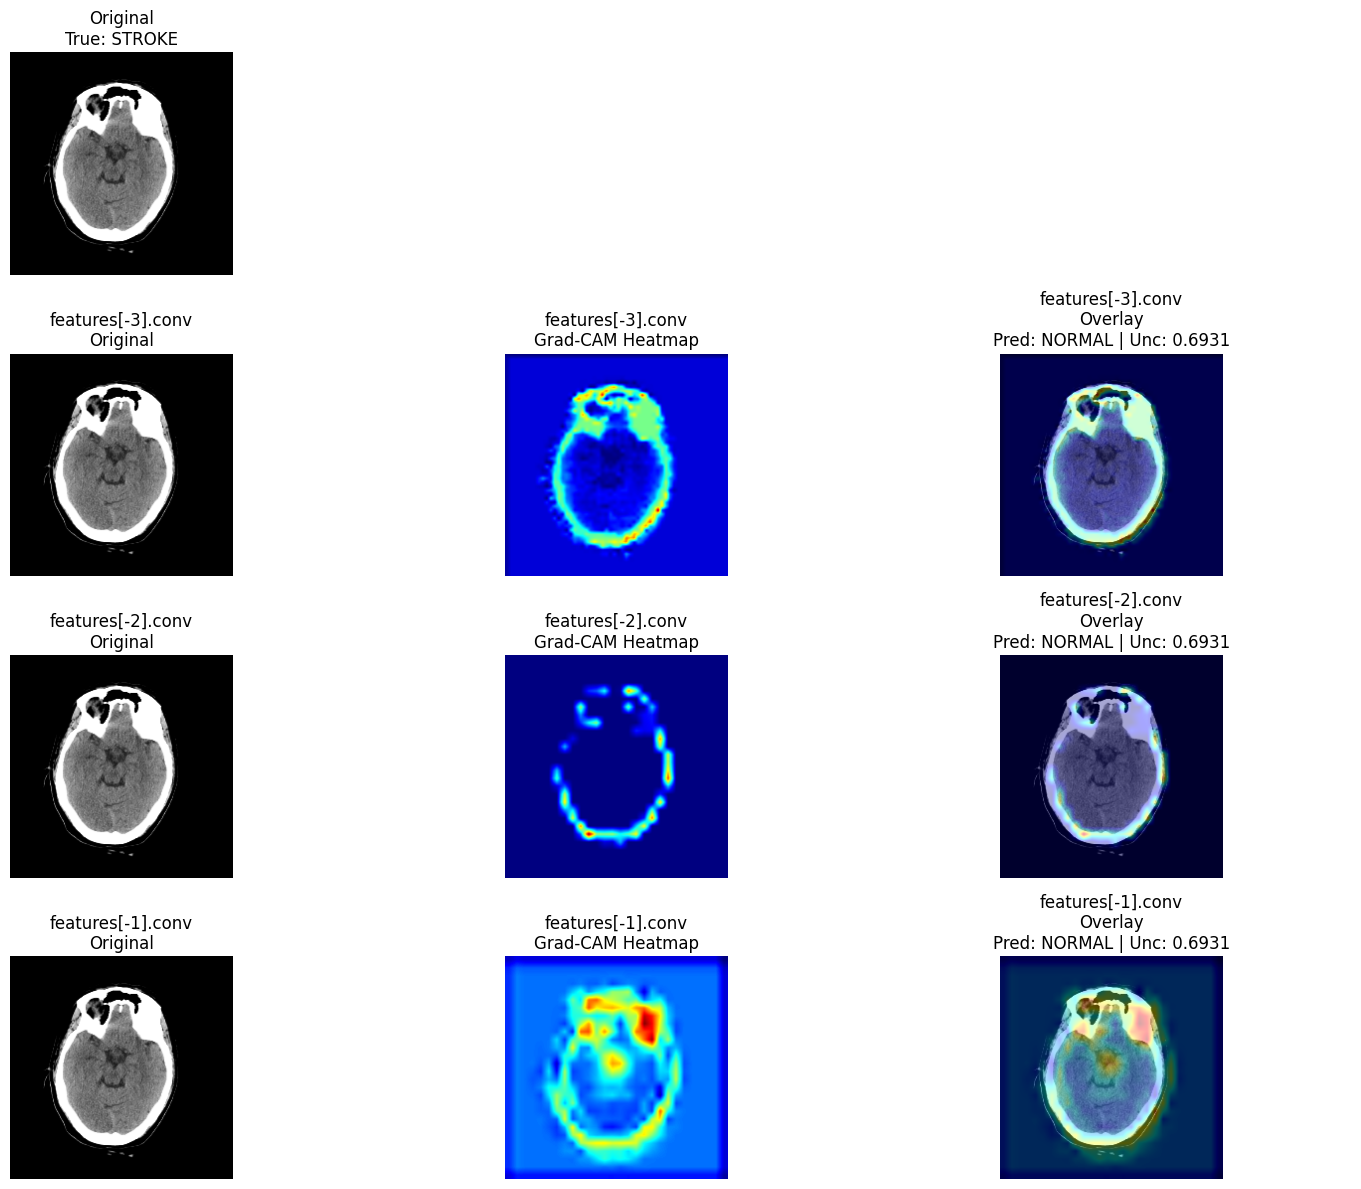

.... Final Prediction Summary ....
True Label      : STROKE
Predicted Label : NORMAL
Decision        : REFERRED_TO_CLINICIAN
Uncertainty     : 0.6931
P(Normal)       : 0.5065
P(Stroke)       : 0.4935
Human-in-the-loop required: uncertainty exceeds safety threshold.

Interpretation Note:
This cell compares Grad-CAM outputs from multiple conv layers.
Earlier layers preserve more spatial detail but can be noisy,
while deeper layers are more class-specific but often too coarse.
Among the tested layers, features[-2].conv provided the most balanced visualization.


In [5]:
"""
An entropy threshold of 0.45 was used for abstention.
Predictions above this uncertainty level were referred to a clinician under the human-in-the-loop safety policy.
"""

# select a stroke example from the test set
selected_img = None
selected_label = None

for img, label in test_loader:
    if int(label.item()) == 1:   # prefer a stroke sample
        selected_img = img.to(device)
        selected_label = label
        break

# if no stroke sample is found, use the first available sample
if selected_img is None:
    selected_img, selected_label = next(iter(test_loader))
    selected_img = selected_img.to(device)

# uncertainty-aware inference
decision, unc, mean_prob, pred_class = agentic_inference(
    model=model,
    image=selected_img,
    n_passes=20,
    threshold=0.45
)

class_names = {0: "NORMAL", 1: "STROKE"}
true_name = class_names[int(selected_label.item())]
pred_name = class_names[int(pred_class)]

# comparation from multiple layers
candidate_layers = [
    ("features[-3].conv", model.features[-3].conv),
    ("features[-2].conv", model.features[-2].conv),
    ("features[-1].conv", model.features[-1].conv),
]

results = []

for layer_name, target_layer in candidate_layers:
    gradcam = GradCAM(model, target_layer)
    cam, cam_class = gradcam.generate(selected_img, class_idx=pred_class)
    orig, heatmap, overlay = overlay_gradcam(selected_img.cpu(), cam)
    results.append((layer_name, orig, heatmap, overlay))
    gradcam.remove_hooks()

# plot comparison
plt.figure(figsize=(15, 12))

# top row-> original image
plt.subplot(4, 3, 1)
plt.imshow(results[0][1], cmap='gray')
plt.title(f"Original\nTrue: {true_name}")
plt.axis('off')

plt.subplot(4, 3, 2)
plt.axis('off')

plt.subplot(4, 3, 3)
plt.axis('off')

# rows 2-4-> one row per candidate layer
for i, (layer_name, orig, heatmap, overlay) in enumerate(results):
    row = i + 2

    plt.subplot(4, 3, (row - 1) * 3 + 1)
    plt.imshow(orig, cmap='gray')
    plt.title(f"{layer_name}\nOriginal")
    plt.axis('off')

    plt.subplot(4, 3, (row - 1) * 3 + 2)
    plt.imshow(heatmap)
    plt.title(f"{layer_name}\nGrad-CAM Heatmap")
    plt.axis('off')

    plt.subplot(4, 3, (row - 1) * 3 + 3)
    plt.imshow(overlay)
    plt.title(
        f"{layer_name}\nOverlay\n"
        f"Pred: {pred_name} | Unc: {unc:.4f}"
    )
    plt.axis('off')

plt.tight_layout()
plt.show()

# 5) Prediction summary
print(".... Final Prediction Summary ....")
print(f"True Label      : {true_name}")
print(f"Predicted Label : {pred_name}")
print(f"Decision        : {decision}")
print(f"Uncertainty     : {unc:.4f}")
print(f"P(Normal)       : {mean_prob[0][0]:.4f}")
print(f"P(Stroke)       : {mean_prob[0][1]:.4f}")

if "REFERRED" in decision:
    print("Human-in-the-loop required: uncertainty exceeds safety threshold.")
else:
    print("Prediction accepted: model is confident enough.")


print("\nInterpretation Note:")
print("This cell compares Grad-CAM outputs from multiple conv layers.")
print("Earlier layers preserve more spatial detail but can be noisy,")
print("while deeper layers are more class-specific but often too coarse.")
print("Among the tested layers, features[-2].conv provided the most balanced visualization.")

.... Quantitative Results ....
Accuracy  : 0.5867
Precision : 0.4292
Recall    : 0.8624
F1-score  : 0.5732

.... Classification Report ....
              precision    recall  f1-score   support

      NORMAL       0.87      0.46      0.60       919
      STROKE       0.43      0.86      0.57       436

    accuracy                           0.59      1355
   macro avg       0.65      0.66      0.59      1355
weighted avg       0.73      0.59      0.59      1355



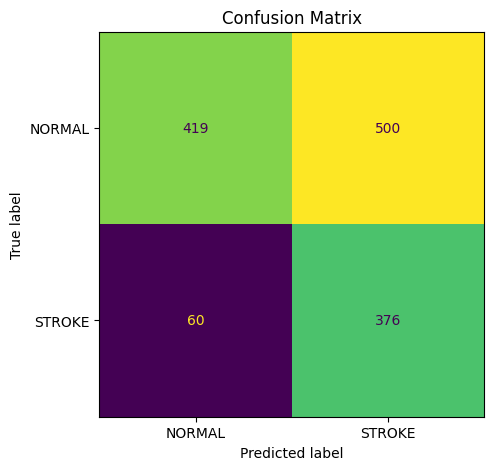

.... Uncertainty / Decision Summary ....
Mean uncertainty       : 0.6359
Median uncertainty     : 0.6624
Min uncertainty        : 0.1895
Max uncertainty        : 0.6931
Accepted predictions   : 45
Referred to clinician  : 1310


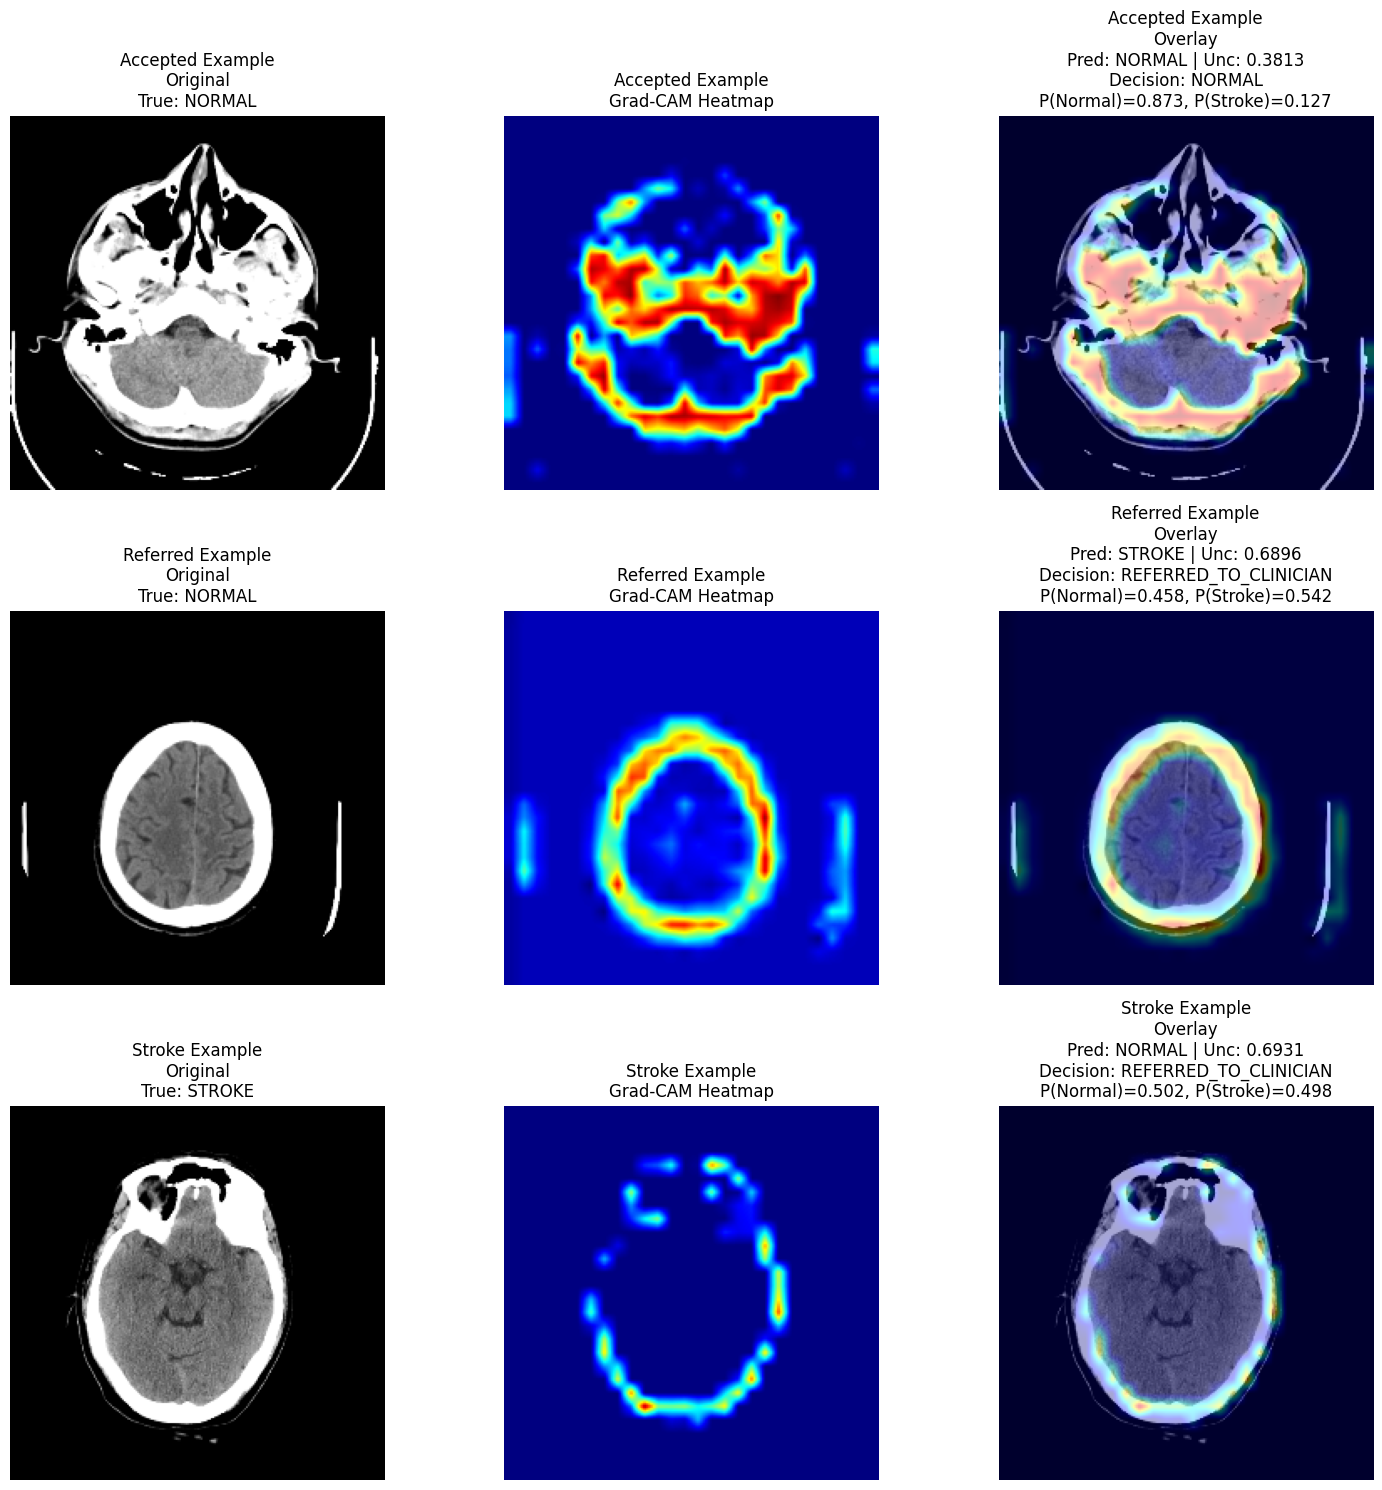


.... Representative Example Summaries ....

Accepted Example:
  True Label      : NORMAL
  Predicted Label : NORMAL
  Decision        : NORMAL
  Uncertainty     : 0.3813
  P(Normal)       : 0.8726
  P(Stroke)       : 0.1274

Referred Example:
  True Label      : NORMAL
  Predicted Label : STROKE
  Decision        : REFERRED_TO_CLINICIAN
  Uncertainty     : 0.6896
  P(Normal)       : 0.4581
  P(Stroke)       : 0.5419

Stroke Example:
  True Label      : STROKE
  Predicted Label : NORMAL
  Decision        : REFERRED_TO_CLINICIAN
  Uncertainty     : 0.6931
  P(Normal)       : 0.5018
  P(Stroke)       : 0.4982


In [6]:
# metrics + representative examples + Grad-CAM visualizations

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

model.eval()

all_true = []
all_pred = []
all_unc = []
all_decisions = []
all_probs = []
all_imgs = []

# collect test predictions with uncertainty
for img, label in test_loader:
    decision, unc, mean_prob, pred_class = agentic_inference(
        model=model,
        image=img,
        n_passes=20,
        threshold=0.45
    )

    all_true.append(int(label.item()))
    all_pred.append(int(pred_class))
    all_unc.append(float(unc))
    all_decisions.append(decision)
    all_probs.append(mean_prob[0])
    all_imgs.append((img.clone(), int(label.item()), int(pred_class), float(unc), decision, mean_prob[0]))

# metrics
acc = accuracy_score(all_true, all_pred)
prec = precision_score(all_true, all_pred, zero_division=0)
rec = recall_score(all_true, all_pred, zero_division=0)
f1 = f1_score(all_true, all_pred, zero_division=0)
cm = confusion_matrix(all_true, all_pred)

print(".... Quantitative Results ....")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1-score  : {f1:.4f}")
print("\n.... Classification Report ....")
print(classification_report(all_true, all_pred, target_names=["NORMAL", "STROKE"], zero_division=0))

# confusion matrix plot
fig, ax = plt.subplots(figsize=(5, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["NORMAL", "STROKE"])
disp.plot(ax=ax, values_format="d", colorbar=False)
plt.title("Confusion Matrix")
plt.show()

# uncertainty statistics
unc_array = np.array(all_unc)
accepted_count = sum("REFERRED" not in d for d in all_decisions)
referred_count = sum("REFERRED" in d for d in all_decisions)

print(".... Uncertainty / Decision Summary ....")
print(f"Mean uncertainty       : {unc_array.mean():.4f}")
print(f"Median uncertainty     : {np.median(unc_array):.4f}")
print(f"Min uncertainty        : {unc_array.min():.4f}")
print(f"Max uncertainty        : {unc_array.max():.4f}")
print(f"Accepted predictions   : {accepted_count}")
print(f"Referred to clinician  : {referred_count}")

# find representative examples
accepted_example = None
referred_example = None
stroke_example = None

for item in all_imgs:
    img, true_label, pred_label, unc, decision, probs = item

    if accepted_example is None and "REFERRED" not in decision:
        accepted_example = item

    if referred_example is None and "REFERRED" in decision:
        referred_example = item

    if stroke_example is None and true_label == 1:
        stroke_example = item

    if accepted_example is not None and referred_example is not None and stroke_example is not None:
        break

examples = [
    ("Accepted Example", accepted_example),
    ("Referred Example", referred_example),
    ("Stroke Example", stroke_example),
]

class_names = {0: "NORMAL", 1: "STROKE"}

# visualize representative examples (Grad-CAM)
target_layer = model.features[-2].conv  # selected best layer from prior comparison

valid_examples = [(title, ex) for title, ex in examples if ex is not None]

if len(valid_examples) == 0:
    print("No representative examples could be selected.")
else:
    plt.figure(figsize=(15, 5 * len(valid_examples)))

    for row_idx, (title, ex) in enumerate(valid_examples, start=1):
        img, true_label, pred_label, unc, decision, probs = ex

        gradcam = GradCAM(model, target_layer)
        cam, cam_class = gradcam.generate(img.to(device), class_idx=pred_label)
        orig, heatmap, overlay = overlay_gradcam(img.cpu(), cam)
        gradcam.remove_hooks()

        plt.subplot(len(valid_examples), 3, (row_idx - 1) * 3 + 1)
        plt.imshow(orig, cmap='gray')
        plt.title(f"{title}\nOriginal\nTrue: {class_names[true_label]}")
        plt.axis("off")

        plt.subplot(len(valid_examples), 3, (row_idx - 1) * 3 + 2)
        plt.imshow(heatmap)
        plt.title(f"{title}\nGrad-CAM Heatmap")
        plt.axis("off")

        plt.subplot(len(valid_examples), 3, (row_idx - 1) * 3 + 3)
        plt.imshow(overlay)
        plt.title(
            f"{title}\nOverlay\n"
            f"Pred: {class_names[pred_label]} | Unc: {unc:.4f}\n"
            f"Decision: {decision}\n"
            f"P(Normal)={probs[0]:.3f}, P(Stroke)={probs[1]:.3f}"
        )
        plt.axis("off")

    plt.tight_layout()
    plt.show()

# representative example summaries
print("\n.... Representative Example Summaries ....")
for title, ex in valid_examples:
    img, true_label, pred_label, unc, decision, probs = ex
    print(f"\n{title}:")
    print(f"  True Label      : {class_names[true_label]}")
    print(f"  Predicted Label : {class_names[pred_label]}")
    print(f"  Decision        : {decision}")
    print(f"  Uncertainty     : {unc:.4f}")
    print(f"  P(Normal)       : {probs[0]:.4f}")
    print(f"  P(Stroke)       : {probs[1]:.4f}")